In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load training data and test predictions from previous notebooks
train_final = pd.read_csv('/home/jupyter/train_final.csv')

# Load test cutter features
test_c2 = pd.read_csv('/home/jupyter/test_c2_features.csv')
test_c3 = pd.read_csv('/home/jupyter/test_c3_features.csv')
test_c5 = pd.read_csv('/home/jupyter/test_c5_features.csv')

# Load physics predictions
physics_df = pd.read_csv('/home/jupyter/physics_predictions.csv')

# Define feature columns
feature_cols = [col for col in train_final.columns 
                if col not in ['cut', 'cutter', 'max_wear']]

print(f"Training data shape: {train_final.shape}")
print(f"Test C2 shape: {test_c2.shape}")
print(f"Test C3 shape: {test_c3.shape}")
print(f"Test C5 shape: {test_c5.shape}")
print(f"Features: {feature_cols}")

Training data shape: (945, 15)
Test C2 shape: (315, 51)
Test C3 shape: (315, 51)
Test C5 shape: (315, 51)
Features: ['vib_x_std', 'vib_x_max', 'force_x_p2p', 'force_y_mean', 'force_x_max', 'vib_y_std', 'force_y_max', 'vib_x_kurtosis', 'vib_y_kurtosis', 'force_y_kurtosis', 'force_y_skewness', 'force_x_kurtosis']


In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.signal import savgol_filter

# Retrain GB model on all training data
X_all = train_final[feature_cols].values
y_all = train_final['max_wear'].values

gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_all, y_all)

# Get raw GB predictions for test cutters
def get_gb_predictions(test_df, model, feature_cols):
    X = test_df[feature_cols].values
    cuts = test_df['cut'].values
    y_pred = model.predict(X)
    return cuts, y_pred

cuts_c2, gb_c2 = get_gb_predictions(test_c2, gb_model, feature_cols)
cuts_c3, gb_c3 = get_gb_predictions(test_c3, gb_model, feature_cols)
cuts_c5, gb_c5 = get_gb_predictions(test_c5, gb_model, feature_cols)

print("GB predictions generated for test cutters")
print(f"C2 predicted wear range: {gb_c2.min():.1f} to {gb_c2.max():.1f}")
print(f"C3 predicted wear range: {gb_c3.min():.1f} to {gb_c3.max():.1f}")
print(f"C5 predicted wear range: {gb_c5.min():.1f} to {gb_c5.max():.1f}")

GB predictions generated for test cutters
C2 predicted wear range: 47.1 to 226.7
C3 predicted wear range: 46.4 to 194.4
C5 predicted wear range: 43.2 to 189.6


In [5]:
class WearKalmanFilter:
    """
    Kalman filter for tool wear estimation.
    
    State: estimated wear at current cut
    Observation: GB model's noisy wear prediction
    Transition: wear increases by expected increment each cut
    """
    
    def __init__(self, initial_wear, process_noise, observation_noise):
        """
        initial_wear:     starting wear estimate (first GB prediction)
        process_noise:    how much wear varies cut to cut (Q)
        observation_noise: how noisy our GB predictions are (R)
        """
        # Initial state estimate
        self.x = initial_wear  # wear estimate
        self.P = 50.0          # initial uncertainty (large = we don't know much yet)
        
        # Noise parameters
        self.Q = process_noise       # process noise
        self.R = observation_noise   # observation noise
    
    def predict(self, wear_increment):
        """
        Step 1 - Predict: project state forward by expected wear increment
        wear_increment: how much we expect wear to increase this cut
        """
        # State prediction - wear increases by expected increment
        self.x = self.x + wear_increment
        
        # Uncertainty increases during prediction
        self.P = self.P + self.Q
        
        return self.x, self.P
    
    def update(self, observation):
        """
        Step 2 - Update: correct prediction using new sensor observation
        observation: GB model's wear prediction for this cut
        """
        # Kalman gain - how much to trust observation vs prediction
        # High K = trust observation more
        # Low K = trust prediction more
        K = self.P / (self.P + self.R)
        
        # Update state estimate
        self.x = self.x + K * (observation - self.x)
        
        # Update uncertainty - decreases after observation
        self.P = (1 - K) * self.P
        
        return self.x, self.P
    
    def step(self, observation, wear_increment):
        """
        Combined predict + update for one cut
        """
        self.predict(wear_increment)
        state, uncertainty = self.update(observation)
        return state, uncertainty



In [6]:
def run_kalman_filter(cuts, gb_predictions, process_noise=5.0, observation_noise=18.0):
    """
    Runs Kalman filter across all cuts for one cutter
    
    cuts:              array of cut numbers
    gb_predictions:    raw GB wear predictions per cut
    process_noise:     Q - expected wear variation cut to cut
    observation_noise: R - GB model error (we use MAE=18 from validation)
    """
    # Initialize filter with first GB prediction
    kf = WearKalmanFilter(
        initial_wear=gb_predictions[0],
        process_noise=process_noise,
        observation_noise=observation_noise
    )
    
    filtered_wear = []
    uncertainty = []
    
    for i in range(len(cuts)):
        # Expected wear increment from physics model
        # Average wear increase per cut across training cutters
        if i == 0:
            wear_increment = 0
        else:
            wear_increment = max(0, gb_predictions[i] - gb_predictions[i-1])
            wear_increment = min(wear_increment, 5.0)  # cap at 5 units per cut
        
        # Run one step
        state, P = kf.step(gb_predictions[i], wear_increment)
        
        # Enforce monotonic increase
        if len(filtered_wear) > 0:
            state = max(state, filtered_wear[-1])
        
        filtered_wear.append(state)
        uncertainty.append(np.sqrt(P))  # convert variance to std deviation
    
    filtered_wear = np.array(filtered_wear)
    uncertainty = np.array(uncertainty)
    
    # Conservative lower bound = filtered estimate - 1 std deviation
    lower_bound = filtered_wear - uncertainty
    upper_bound = filtered_wear + uncertainty
    
    return filtered_wear, lower_bound, upper_bound, uncertainty


In [7]:
# Run Kalman filter on test cutters
filtered_c2, lower_c2, upper_c2, unc_c2 = run_kalman_filter(cuts_c2, gb_c2)
filtered_c3, lower_c3, upper_c3, unc_c3 = run_kalman_filter(cuts_c3, gb_c3)
filtered_c5, lower_c5, upper_c5, unc_c5 = run_kalman_filter(cuts_c5, gb_c5)

print("Kalman filter complete for all test cutters")
print(f"\nC2 filtered wear range: {filtered_c2.min():.1f} to {filtered_c2.max():.1f}")
print(f"C3 filtered wear range: {filtered_c3.min():.1f} to {filtered_c3.max():.1f}")
print(f"C5 filtered wear range: {filtered_c5.min():.1f} to {filtered_c5.max():.1f}")

print(f"\nC2 average uncertainty: {unc_c2.mean():.2f}")
print(f"C3 average uncertainty: {unc_c3.mean():.2f}")
print(f"C5 average uncertainty: {unc_c5.mean():.2f}")

Kalman filter complete for all test cutters

C2 filtered wear range: 50.6 to 227.9
C3 filtered wear range: 57.3 to 194.5
C5 filtered wear range: 43.2 to 189.7

C2 average uncertainty: 2.71
C3 average uncertainty: 2.71
C5 average uncertainty: 2.71


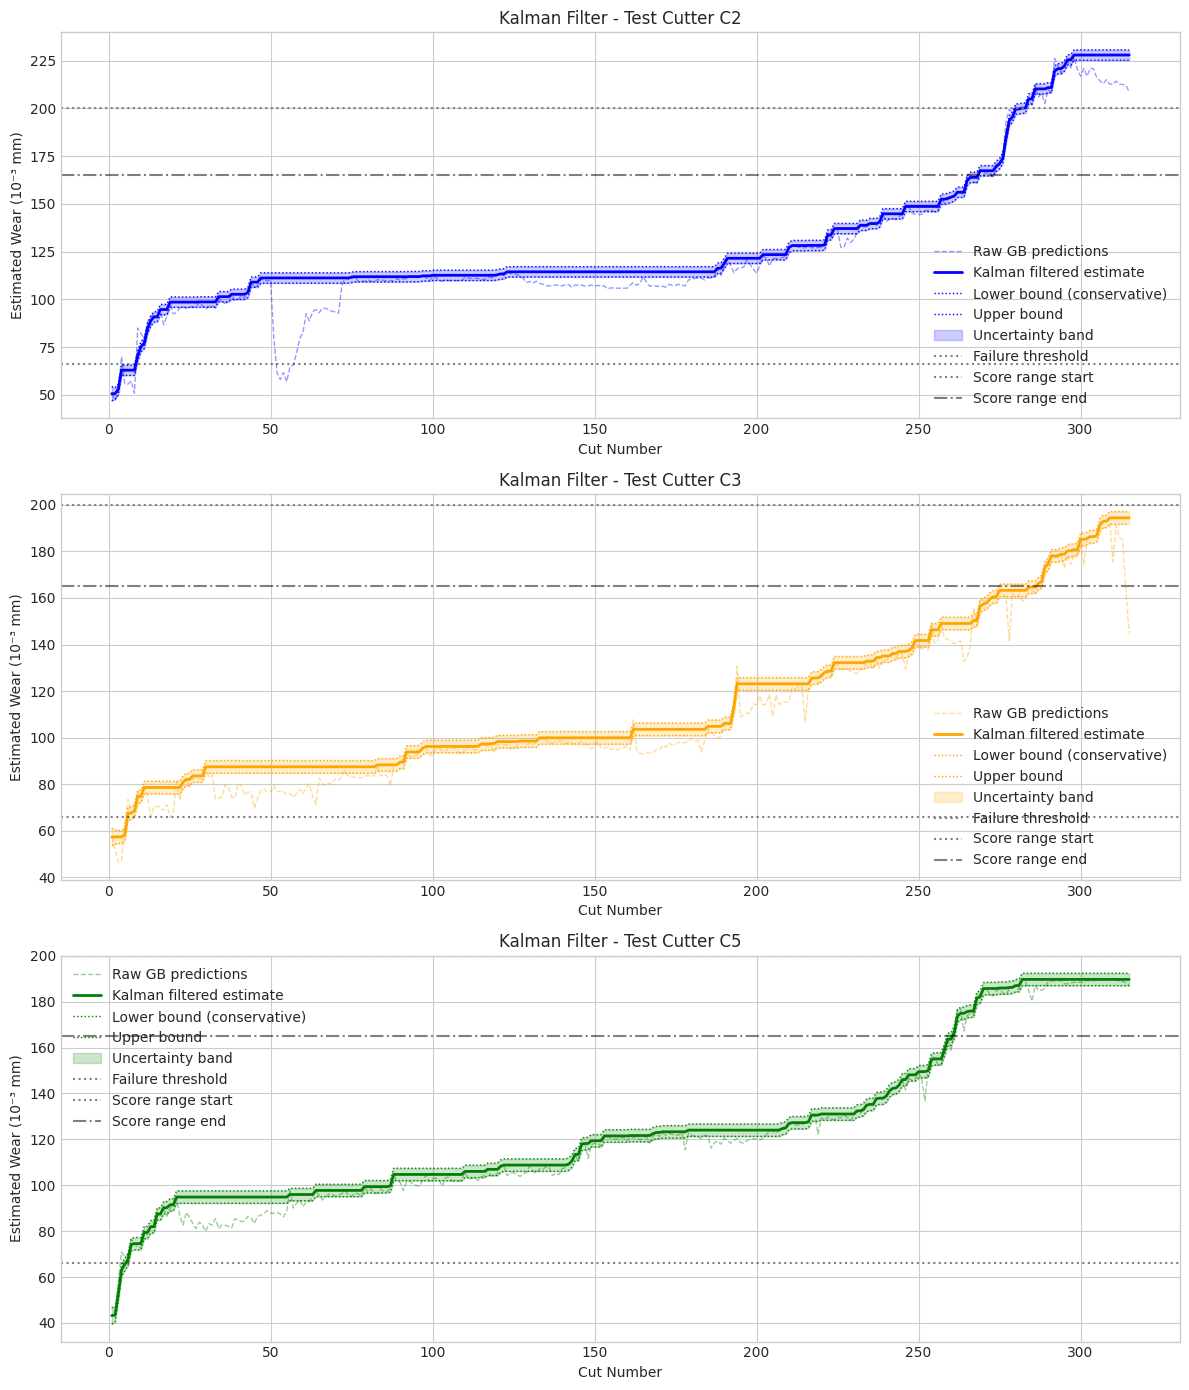

Plot saved


In [8]:
# Plot Kalman filter results for test cutters
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

test_cutters = ['c2', 'c3', 'c5']
cuts_list = [cuts_c2, cuts_c3, cuts_c5]
gb_list = [gb_c2, gb_c3, gb_c5]
filtered_list = [filtered_c2, filtered_c3, filtered_c5]
lower_list = [lower_c2, lower_c3, lower_c5]
upper_list = [upper_c2, upper_c3, upper_c5]
colors = {'c2': 'blue', 'c3': 'orange', 'c5': 'green'}

for ax, cutter, cuts, gb, filtered, lower, upper in zip(
        axes, test_cutters, cuts_list, gb_list, 
        filtered_list, lower_list, upper_list):
    
    # Raw GB predictions
    ax.plot(cuts, gb, color=colors[cutter], linewidth=1, 
            alpha=0.4, linestyle='--', label='Raw GB predictions')
    
    # Kalman filtered estimate
    ax.plot(cuts, filtered, color=colors[cutter], 
            linewidth=2, label='Kalman filtered estimate')
    
    # Uncertainty bounds
    ax.plot(cuts, lower, color=colors[cutter], linewidth=1,
            linestyle=':', label='Lower bound (conservative)')
    ax.plot(cuts, upper, color=colors[cutter], linewidth=1,
            linestyle=':', label='Upper bound')
    
    # Shade uncertainty band
    ax.fill_between(cuts, lower, upper, 
                    alpha=0.2, color=colors[cutter], label='Uncertainty band')
    
    ax.axhline(y=200, color='gray', linestyle=':', label='Failure threshold')
    ax.axhline(y=66, color='black', linestyle=':', alpha=0.5, label='Score range start')
    ax.axhline(y=165, color='black', linestyle='-.', alpha=0.5, label='Score range end')
    
    ax.set_title(f'Kalman Filter - Test Cutter {cutter.upper()}')
    ax.set_xlabel('Cut Number')
    ax.set_ylabel('Estimated Wear (10⁻³ mm)')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/kalman_filter_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [9]:
# Generate Kalman filter challenge submission
wear_thresholds = np.arange(66, 166)

def predict_safe_cuts(wear_curve, cuts, wear_thresholds):
    predictions = []
    for W in wear_thresholds:
        crossing = np.where(wear_curve >= W)[0]
        if len(crossing) > 0:
            predictions.append(int(cuts[crossing[0]]))
        else:
            predictions.append(int(cuts[-1] + 10))
    return predictions

# Use lower bound for conservative estimates
kalman_submission = []

for cutter, cuts, lower in [('c2', cuts_c2, lower_c2),
                              ('c3', cuts_c3, lower_c3),
                              ('c5', cuts_c5, lower_c5)]:
    safe_cuts = predict_safe_cuts(lower, cuts, wear_thresholds)
    for W, sc in zip(wear_thresholds, safe_cuts):
        kalman_submission.append({
            'cutter': cutter,
            'wear_threshold': W,
            'estimated_safe_cuts': sc
        })

kalman_df = pd.DataFrame(kalman_submission)

print("Kalman filter submission generated")
print(f"Shape: {kalman_df.shape}")
print(f"\nSample predictions for C2:")
print(kalman_df[kalman_df['cutter']=='c2'].head(10))

Kalman filter submission generated
Shape: (300, 3)

Sample predictions for C2:
  cutter  wear_threshold  estimated_safe_cuts
0     c2              66                    9
1     c2              67                    9
2     c2              68                   10
3     c2              69                   10
4     c2              70                   10
5     c2              71                   10
6     c2              72                   10
7     c2              73                   11
8     c2              74                   11
9     c2              75                   12


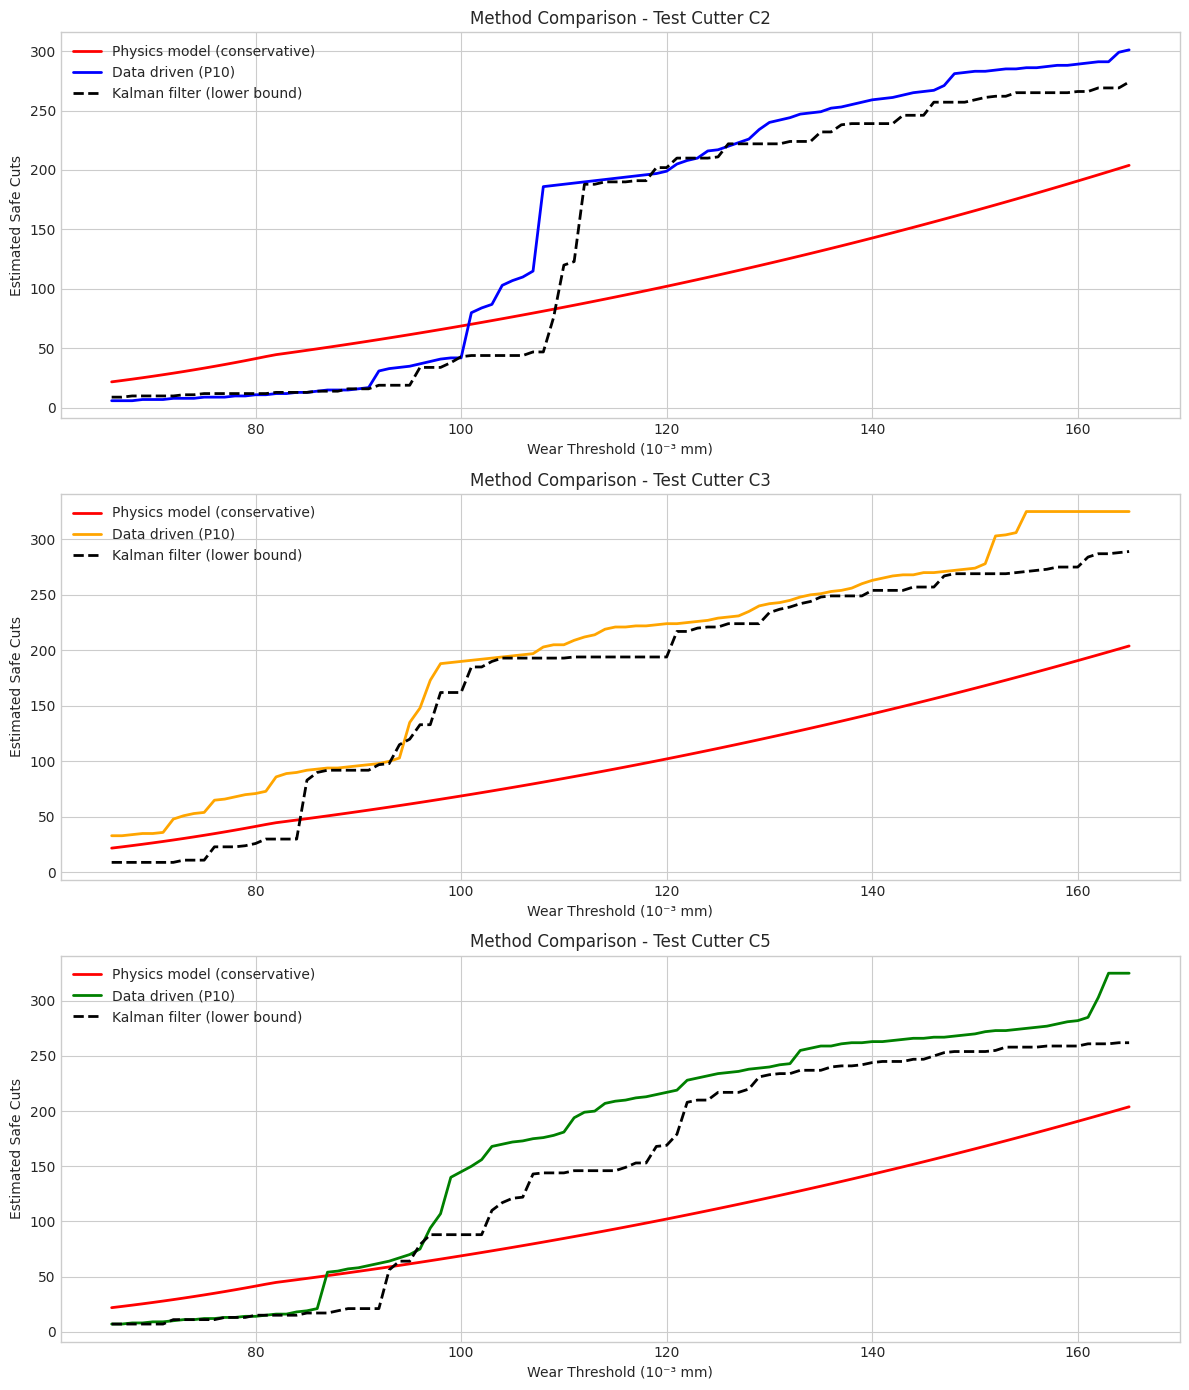

Plot saved


In [10]:
# Load data driven submission for comparison
dd_submission = pd.read_csv('/home/jupyter/submission_data_driven.csv')

# Compare all three methods
fig, axes = plt.subplots(3, 1, figsize=(12, 14))

test_cutters = ['c2', 'c3', 'c5']
colors = {'c2': 'blue', 'c3': 'orange', 'c5': 'green'}

for ax, cutter in zip(axes, test_cutters):
    # Physics model
    physics_pred = physics_df['conservative'].values
    
    # Data driven model
    dd_pred = dd_submission[dd_submission['cutter']==cutter]['estimated_safe_cuts'].values
    
    # Kalman filter
    kf_pred = kalman_df[kalman_df['cutter']==cutter]['estimated_safe_cuts'].values
    
    ax.plot(wear_thresholds, physics_pred, color='red', 
            linewidth=2, label='Physics model (conservative)')
    ax.plot(wear_thresholds, dd_pred, color=colors[cutter], 
            linewidth=2, label='Data driven (P10)')
    ax.plot(wear_thresholds, kf_pred, color='black', 
            linewidth=2, linestyle='--', label='Kalman filter (lower bound)')
    
    ax.set_title(f'Method Comparison - Test Cutter {cutter.upper()}')
    ax.set_xlabel('Wear Threshold (10⁻³ mm)')
    ax.set_ylabel('Estimated Safe Cuts')
    ax.legend()

plt.tight_layout()
plt.savefig('/home/jupyter/plots/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")